In [1]:
import sys
sys.path.append('../../' \
'')
import glob
import os
import scipy.io
from scipy.io import loadmat
import nrrd
from dipy.io.image import load_nifti
from dipy.io.gradients import read_bvals_bvecs
import matplotlib.pyplot as plt
import time

from skimage.measure import label
import numpy as np
from skimage.transform import hough_circle, hough_circle_peaks
from skimage.feature import canny
from skimage.morphology import flood_fill

from skimage.measure import label
import numpy as np


import sys
sys.path.append('CarDpy-master')
import glob
import os
import nrrd
from dipy.io.image import load_nifti
from dipy.io.gradients import read_bvals_bvecs
import matplotlib.pyplot as plt
import time
# from mystic_mrpy.Data_Sorting.Diffusion            import *
from cardpy.Data_Sorting import *
from skimage.measure import label
import numpy as np
from skimage.transform import hough_circle, hough_circle_peaks
from skimage.feature import canny
from skimage.morphology import flood_fill
from cardpy.Data_Processing.DTI import DTI_recon
from cardpy.Data_Processing.DWI import DWI_recon
# from mystic_mrpy.Diffusion.DTI import DWI_recon
# from mystic_mrpy.Colormaps.Diffusion import cDWI_Colormaps_Generator
from cardpy.Colormaps import *
# from mystic_mrpy.Data_Saving.Diffusion   import *
from cardpy.Data_Saving import *

# from mystic_mrpy.Diffusion.Registration            import *
# from mystic_mrpy.Diffusion.Denoising               import *
# from mystic_mrpy.Diffusion.Interpolation           import *
from cardpy.Data_Processing.Registration import *
from cardpy.Data_Processing.Denoising import *
from cardpy.Data_Processing.Interpolation import *
from cardpy.Data_Processing.Diffusivity import *

from   cardpy.Data_Import          import *
from   cardpy.Data_Sorting         import *
from   cardpy.Data_Processing.DTI  import *
from   cardpy.Data_Processing.cDTI import * 
import numpy                       as     np
from   cardpy.Colormaps            import * 
from   cardpy.GUI_Tools.IntERCOMS  import * 

cDTI_cmaps     = cDTI_Colormaps_Generator()

In [2]:
main_path = '/Volumes/T7/Stim-CODE/'

main_data_path         = os.path.join(main_path,'Bootstrapping')
main_image_path        = os.path.join(main_path,'Bootstrapping')
main_segmentation_path = os.path.join(main_path,'NifTi')
main_maps_outpath =os.path.join(main_path,'Bootstrapping')

volunteers        =     ['Phantom_Head_repeat']#['V001','V002', 'V003', 'V004', 'V005', 
                    #'V006', 'V007','V008','V009','V010' ] #,
Folder       = ['ep2d_diff_m0_ext_b1000_sos_mmt0', 'gropt_mmt0_Ncalib2',
                'gropt_mmt1_Ncalib2','trap_mmt0_Ncalib2','trap_mmt1_Ncalib2']

Path to NRRD images:  /Volumes/T7/Stim-CODE/NifTi/Phantom_Head_repeat/mask1.nrrd
Path to header:       /Volumes/T7/Stim-CODE/Bootstrapping/Phantom_Head_repeat/ep2d_diff_m0_ext_b1000_sos_mmt0/01_Registered_400_Bootstraps/Registered_400_Bootstraps.header
Path to NifTi images: /Volumes/T7/Stim-CODE/Bootstrapping/Phantom_Head_repeat/ep2d_diff_m0_ext_b1000_sos_mmt0/01_Registered_400_Bootstraps/Registered_400_Bootstraps.nii
{'Manufacturer': 'Siemens', 'Scanner Model': 'CIMA.X', 'Magnet Strength': '3.0', 'Patient ID': 'TEST', 'Patient Age': 'XX', 'Patient Sex': 'X', 'Partial Fourier': '6/8', 'X Resolution': 0.75, 'Y Resolution': 0.75, 'Z Resolution': 1.5}
Path to DTI Metrics:  /Volumes/T7/Stim-CODE/Bootstrapping/Phantom_Head_repeat/ep2d_diff_m0_ext_b1000_sos_mmt0/04_Standard_DWI_Metrics_400_Bootstraps/Standard_DWI_Metrics_400_Bootstraps.mat
Slice 1 of 1


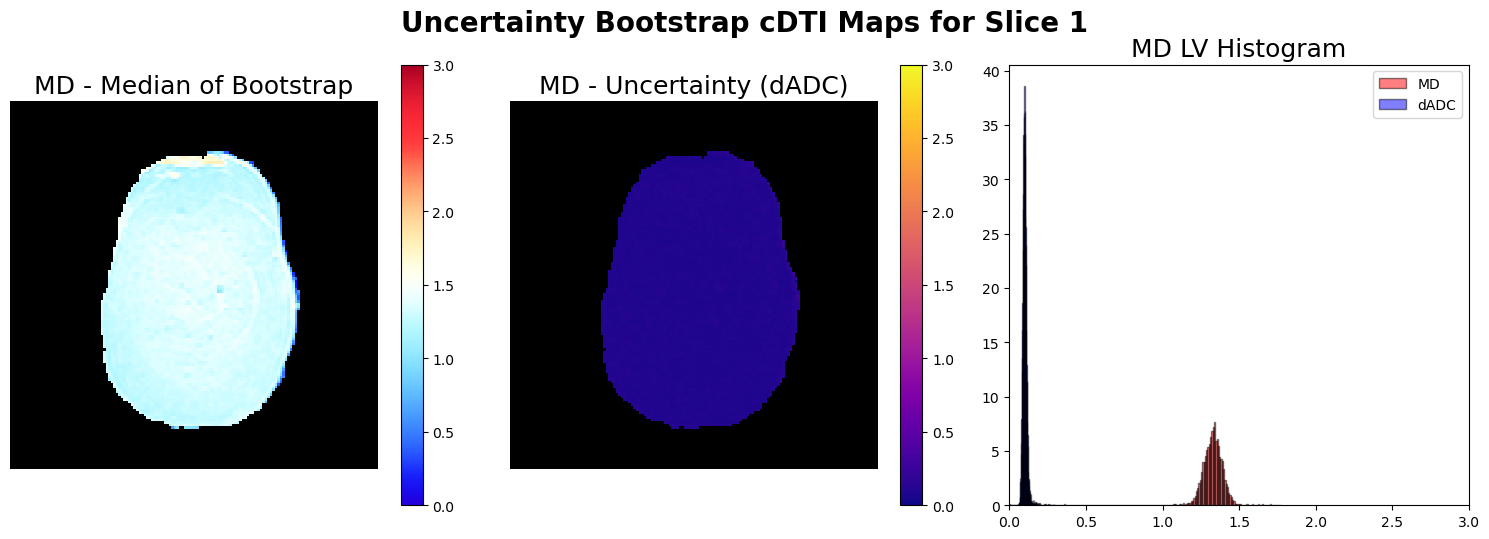

Path to NRRD images:  /Volumes/T7/Stim-CODE/NifTi/Phantom_Head_repeat/mask1.nrrd
Path to header:       /Volumes/T7/Stim-CODE/Bootstrapping/Phantom_Head_repeat/gropt_mmt0_Ncalib2/01_Registered_400_Bootstraps/Registered_400_Bootstraps.header
Path to NifTi images: /Volumes/T7/Stim-CODE/Bootstrapping/Phantom_Head_repeat/gropt_mmt0_Ncalib2/01_Registered_400_Bootstraps/Registered_400_Bootstraps.nii
{'Manufacturer': 'Siemens', 'Scanner Model': 'CIMA.X', 'Magnet Strength': '3.0', 'Patient ID': 'TEST', 'Patient Age': 'XX', 'Patient Sex': 'X', 'Partial Fourier': '6/8', 'X Resolution': 0.75, 'Y Resolution': 0.75, 'Z Resolution': 1.5}
Path to DTI Metrics:  /Volumes/T7/Stim-CODE/Bootstrapping/Phantom_Head_repeat/gropt_mmt0_Ncalib2/04_Standard_DWI_Metrics_400_Bootstraps/Standard_DWI_Metrics_400_Bootstraps.mat
Slice 1 of 1


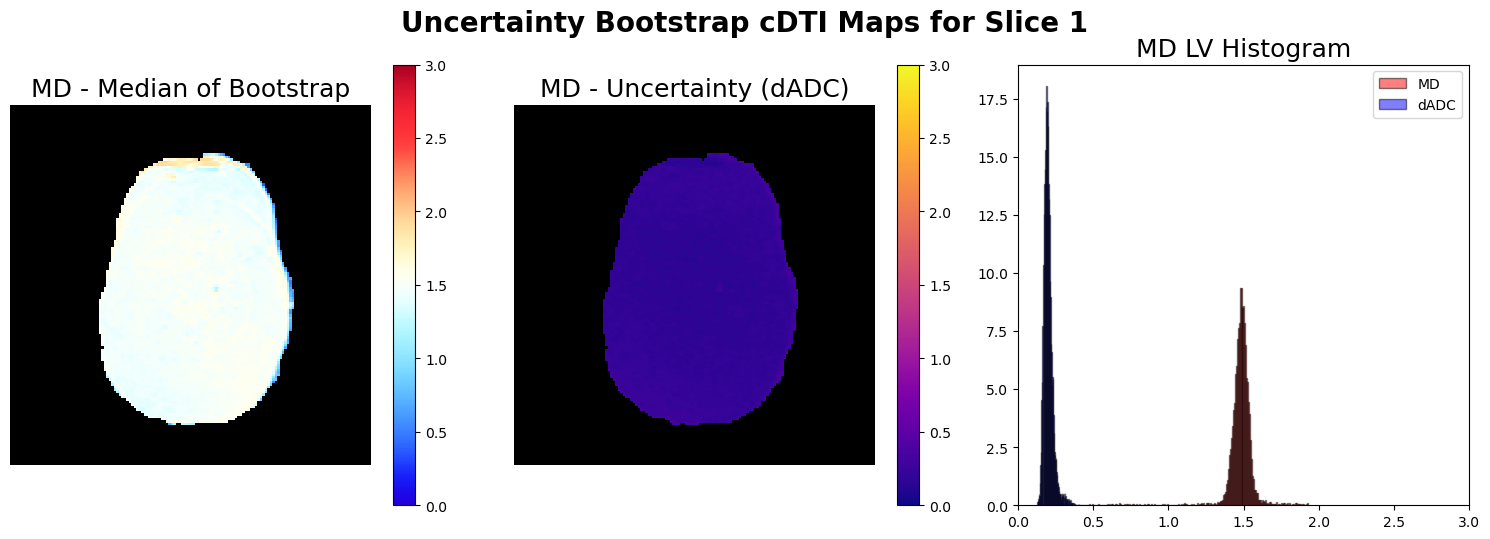

Path to NRRD images:  /Volumes/T7/Stim-CODE/NifTi/Phantom_Head_repeat/mask1.nrrd
Path to header:       /Volumes/T7/Stim-CODE/Bootstrapping/Phantom_Head_repeat/gropt_mmt1_Ncalib2/01_Registered_400_Bootstraps/Registered_400_Bootstraps.header
Path to NifTi images: /Volumes/T7/Stim-CODE/Bootstrapping/Phantom_Head_repeat/gropt_mmt1_Ncalib2/01_Registered_400_Bootstraps/Registered_400_Bootstraps.nii
{'Manufacturer': 'Siemens', 'Scanner Model': 'CIMA.X', 'Magnet Strength': '3.0', 'Patient ID': 'TEST', 'Patient Age': 'XX', 'Patient Sex': 'X', 'Partial Fourier': '6/8', 'X Resolution': 0.75, 'Y Resolution': 0.75, 'Z Resolution': 1.5}
Path to DTI Metrics:  /Volumes/T7/Stim-CODE/Bootstrapping/Phantom_Head_repeat/gropt_mmt1_Ncalib2/04_Standard_DWI_Metrics_400_Bootstraps/Standard_DWI_Metrics_400_Bootstraps.mat
Slice 1 of 1


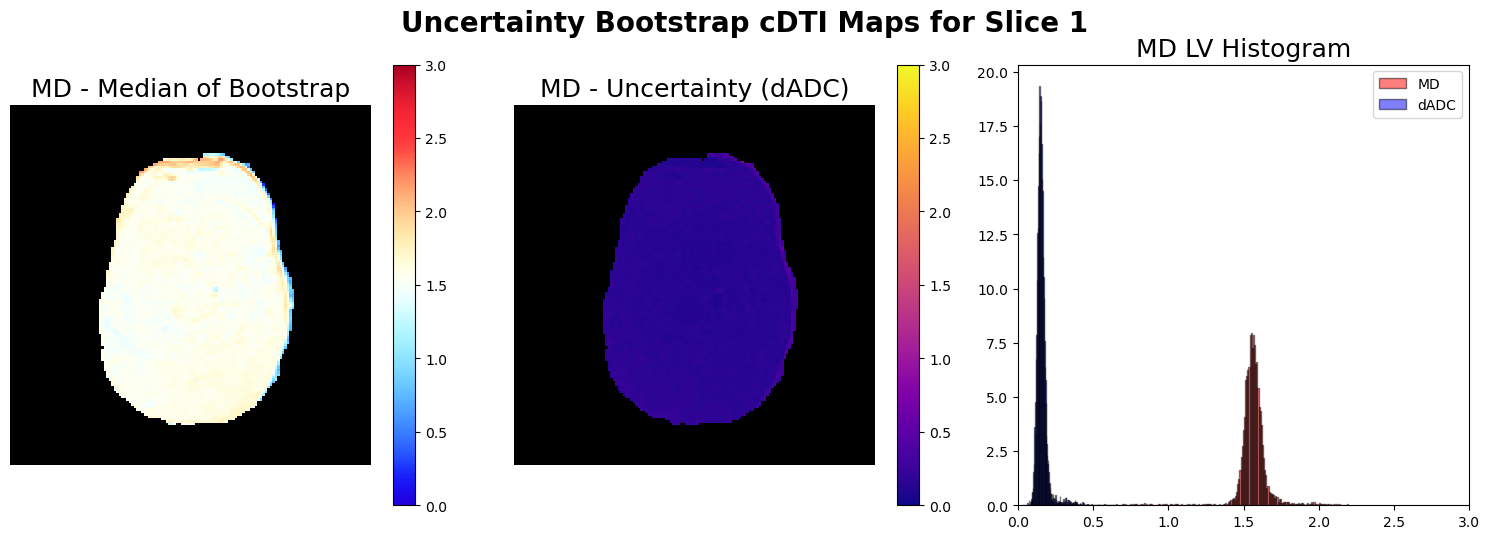

Path to NRRD images:  /Volumes/T7/Stim-CODE/NifTi/Phantom_Head_repeat/mask1.nrrd
Path to header:       /Volumes/T7/Stim-CODE/Bootstrapping/Phantom_Head_repeat/trap_mmt0_Ncalib2/01_Registered_400_Bootstraps/Registered_400_Bootstraps.header
Path to NifTi images: /Volumes/T7/Stim-CODE/Bootstrapping/Phantom_Head_repeat/trap_mmt0_Ncalib2/01_Registered_400_Bootstraps/Registered_400_Bootstraps.nii
{'Manufacturer': 'Siemens', 'Scanner Model': 'CIMA.X', 'Magnet Strength': '3.0', 'Patient ID': 'TEST', 'Patient Age': 'XX', 'Patient Sex': 'X', 'Partial Fourier': '6/8', 'X Resolution': 0.75, 'Y Resolution': 0.75, 'Z Resolution': 1.5}
Path to DTI Metrics:  /Volumes/T7/Stim-CODE/Bootstrapping/Phantom_Head_repeat/trap_mmt0_Ncalib2/04_Standard_DWI_Metrics_400_Bootstraps/Standard_DWI_Metrics_400_Bootstraps.mat
Slice 1 of 1


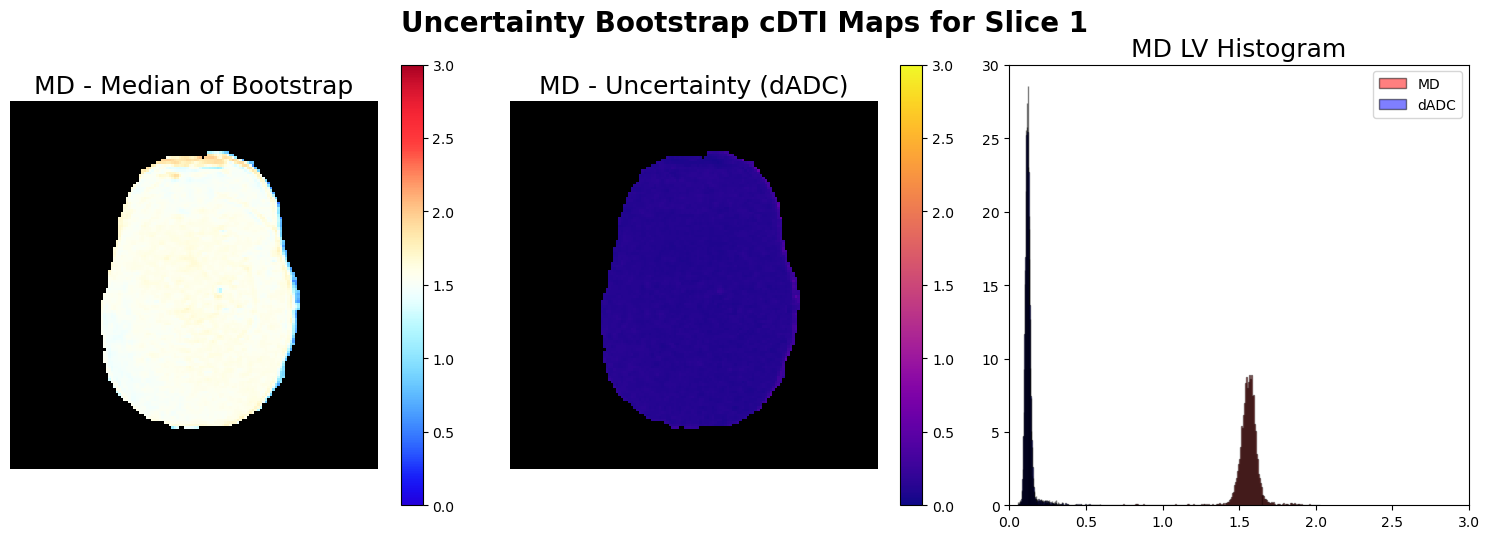

Path to NRRD images:  /Volumes/T7/Stim-CODE/NifTi/Phantom_Head_repeat/mask1.nrrd
Path to header:       /Volumes/T7/Stim-CODE/Bootstrapping/Phantom_Head_repeat/trap_mmt1_Ncalib2/01_Registered_400_Bootstraps/Registered_400_Bootstraps.header
Path to NifTi images: /Volumes/T7/Stim-CODE/Bootstrapping/Phantom_Head_repeat/trap_mmt1_Ncalib2/01_Registered_400_Bootstraps/Registered_400_Bootstraps.nii
{'Manufacturer': 'Siemens', 'Scanner Model': 'CIMA.X', 'Magnet Strength': '3.0', 'Patient ID': 'TEST', 'Patient Age': 'XX', 'Patient Sex': 'X', 'Partial Fourier': '6/8', 'X Resolution': 0.75, 'Y Resolution': 0.75, 'Z Resolution': 1.5}
Path to DTI Metrics:  /Volumes/T7/Stim-CODE/Bootstrapping/Phantom_Head_repeat/trap_mmt1_Ncalib2/04_Standard_DWI_Metrics_400_Bootstraps/Standard_DWI_Metrics_400_Bootstraps.mat
Slice 1 of 1


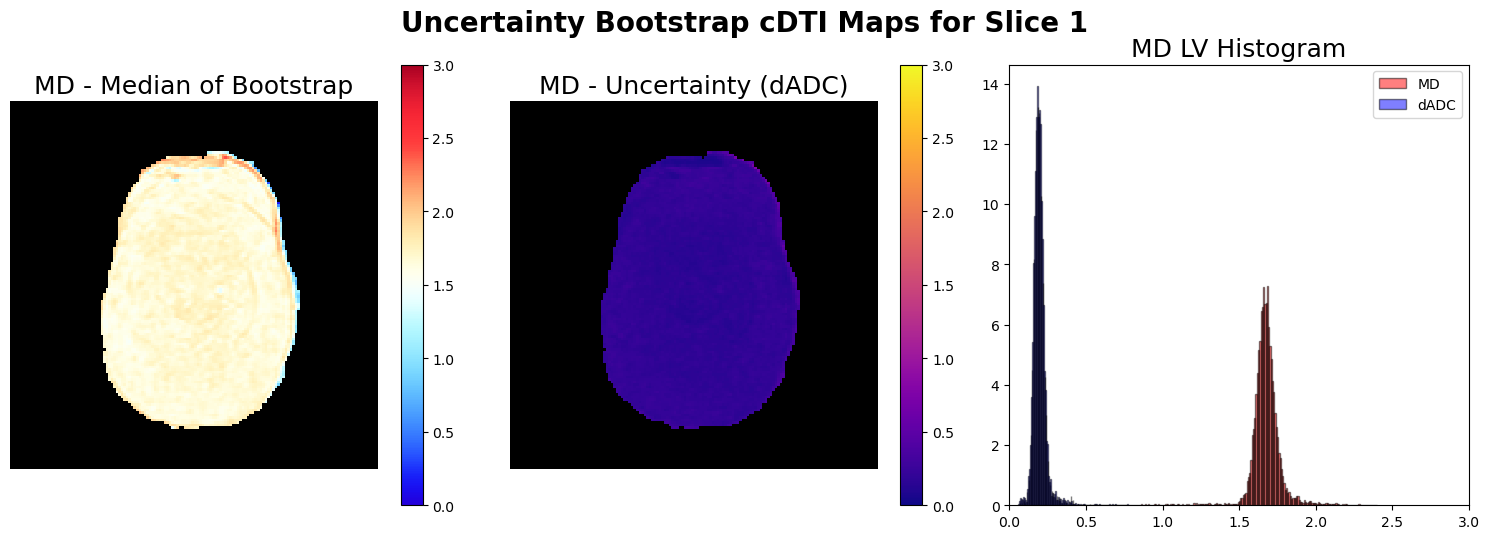

0.1093979835510254


In [3]:
import time

def Header_Reader(header_path):
    with open(header_path) as f:
        lines = f.readlines()
    HeadersDict = dict()
    for idx in range(len(lines)):
        key_word              = lines[idx].split(':')[0]
        key_value             = lines[idx].split(':')[1]
        key_value             = key_value.strip()
        key_value_clear       = key_value.split(' ')[0]
        HeadersDict[key_word] = key_value_clear
    return HeadersDict


def calc_95_CI(data, number_of_bins = 1000):
    import numpy as np
#     min_value = np.min(data)
#     max_value = np.max(data)
#     bin_width = (max_bootstrap - min_bootstrap) / 100
    
    [vals, bin_edges] = np.histogram(data, bins = number_of_bins)
    h = vals / np.sum(vals)  
    ### Find lower bound index (j)
    j = 0
    test = 0
    while (test <= 0.025):
        test = test + h[j]
        if (test <= 0.025):
            j = j + 1
        if (test > 0.025):
            if j == 0:
                j = j
            else:
                j = j - 1
    ### Find upper bound index (k)
    k = len(h) - 1
    test = 0
    while (test <= 0.025):
        test = test + h[k]
        if (test <= 0.025):
            k = k - 1
        if (test > 0.025):
            k = k + 1

    lower_bound = ((bin_edges[j + 1] - bin_edges[j]) /2) + bin_edges[j]
    upper_bound = ((bin_edges[k - 1] - bin_edges[k]) /2) + bin_edges[k]
    return [lower_bound, upper_bound]

def Invariant_Uncertainty(Bootstrapped_Standard_DWI_Metrics):
    import numpy as np
    
    rows = Bootstrapped_Standard_DWI_Metrics['ADC'].shape[0]
    cols = Bootstrapped_Standard_DWI_Metrics['ADC'].shape[1]
    slcs = Bootstrapped_Standard_DWI_Metrics['ADC'].shape[2]
    
    dADC = np.zeros([rows, cols, slcs])


    mADC = np.zeros([rows, cols, slcs])

    for x in range(rows):
        for y in range(cols):
            for slc in range(slcs):
                data   = Bootstrapped_Standard_DWI_Metrics['ADC'][x, y, slc, :].flatten()
                data_2 = data[~(np.isnan(data))]
#                 [LB, UB] = calc_95_CI(data_2)
                data_sorted       = np.sort(data_2)
                Upper_Bound_Index = len(data_sorted) - int(np.round(0.025 * len(data_sorted), 0)) - 1
                Lower_Bound_Index = int(np.round(0.025 * len(data_sorted), 0)) - 1
                UB = data_sorted[Upper_Bound_Index]
                LB = data_sorted[Lower_Bound_Index]
                dADC[x, y, slc] = UB - LB
                mADC[x, y, slc] = np.median(data_2)
                del data, data_2, data_sorted, Upper_Bound_Index, Lower_Bound_Index, LB, UB

    Invariant_Uncertainties = dict()
    Invariant_Uncertainties['dADC'] =  dADC

    Invariant_Medians = dict()
    Invariant_Medians['mADC'] =  mADC

    return [Invariant_Uncertainties, Invariant_Medians]



overal_start_time = time.time()


for subject_folder in volunteers:


    

                    #'nice_diff_gropt_2x2x8_b400','nice_diff_trap_2x2x8_b400', #
                    #'nice_diff_gropt_2x2x8_b1200','nice_diff_trap_2x2x8_b1200',]
    # Folder      = 'DiVO_06_10'
    Data_Folder = '01_Registered_400_Bootstraps'
    Evals_Folder = '04_Standard_DWI_Metrics_400_Bootstraps'


    for flid in range(len(Folder)):
        inpath_1 = glob.glob(os.path.join(main_segmentation_path, subject_folder,  'mask1.nrrd'))[0]
        print('Path to NRRD images:  ' + inpath_1)
        NRRD = nrrd.read(inpath_1)[0]

        inpath_2 = glob.glob(os.path.join(main_image_path, subject_folder,  Folder[flid], Data_Folder, 'Registered_400_Bootstraps.header'))[0]
        print('Path to header:       ' + inpath_2)
        Header = Header_Reader(inpath_2)

        inpath_3 = glob.glob(os.path.join(main_image_path, subject_folder,  Folder[flid], Data_Folder, 'Registered_400_Bootstraps.nii'))[0]
        print('Path to NifTi images: ' + inpath_3)
        NifTi, affine_matrix, NifTi_VoxRes = load_nifti(inpath_3, return_voxsize = True)

        Header['X Resolution'] = NifTi_VoxRes[0]
        Header['Y Resolution'] = NifTi_VoxRes[1]
        Header['Z Resolution'] = NifTi_VoxRes[2]
        print(Header)

        inpath_4 = glob.glob(os.path.join(main_data_path, subject_folder,  Folder[flid], Evals_Folder, 'Standard_DWI_Metrics_400_Bootstraps.mat'))[0]
        print('Path to DTI Metrics:  ' + inpath_4)
        mat = scipy.io.loadmat(inpath_4)
        
        Bootstrapped_ADC = mat['ADC']

        Bootstrapped_Standard_DWI_Metrics = dict()
        Bootstrapped_Standard_DWI_Metrics['ADC'] = Bootstrapped_ADC

        
        [Invariant_Uncertainties, Invariant_Medians] = Invariant_Uncertainty(Bootstrapped_Standard_DWI_Metrics)

        matrix = np.real(NifTi)
        myocardial_mask_smoothed = np.copy(NRRD)
        myocardial_mask_smoothed_nan = np.copy(myocardial_mask_smoothed)
        myocardial_mask_smoothed_nan = myocardial_mask_smoothed_nan.astype('float')
        myocardial_mask_smoothed_nan [myocardial_mask_smoothed_nan == 0] = np.nan

        # flip mask
        myocardial_mask_smoothed_nan = np.flip(myocardial_mask_smoothed_nan, axis=0)

        vmax_image = 200

        if not os.path.exists(os.path.join(main_maps_outpath, subject_folder, Folder[flid])):
                # If it doesn't exist, create it
                os.makedirs(os.path.join(main_maps_outpath, subject_folder, Folder[flid]))

        for slc in range(myocardial_mask_smoothed_nan.shape[2]):

            print('Slice %i of %i' %(slc + 1, myocardial_mask_smoothed_nan.shape[2]))
            fig = plt.figure(figsize = (15, 15), dpi= 100)
            fig.patch.set_facecolor('white')
            fig.suptitle('Uncertainty Bootstrap cDTI Maps for Slice %i' %(slc + 1), fontsize = 20, fontweight='bold')
            plt.subplot(3,3,1)
            plt.imshow(np.real(matrix[:, :, slc, 0]), vmin = 0, vmax = vmax_image, cmap = 'gray')
            plt.imshow(Invariant_Medians['mADC'][:, :, slc] * myocardial_mask_smoothed_nan[:, :, slc], vmin = 0, vmax = 3, cmap = cDTI_cmaps['MD'], interpolation = 'nearest')
            plt.axis('off')
            plt.ylabel('Mean Diffusivity')
            plt.colorbar()
            plt.title('MD - Median of Bootstrap', fontsize = 18)

            plt.subplot(3,3,2)
            plt.imshow(matrix[:, :, slc, 0], vmin = 0, vmax = vmax_image, cmap = 'gray')
            plt.imshow(Invariant_Uncertainties['dADC'][:, :, slc] * myocardial_mask_smoothed_nan[:, :, slc], vmin = 0, vmax = 3, cmap = 'plasma', interpolation = 'nearest')
            plt.axis('off')
            plt.colorbar()
            plt.title('MD - Uncertainty (dADC)', fontsize = 18)

            plt.subplot(3,3,3)
            data1_nan = Invariant_Medians['mADC'][:, :, slc] * myocardial_mask_smoothed_nan[:, :, slc]
            data1_nan = data1_nan.flatten()
            data1 = data1_nan[~(np.isnan(data1_nan))]
            q25, q75 = np.percentile(data1, [25, 75])
            bin_width = 2 * (q75 - q25) * len(data1) ** (-1/3)
            bins = round((data1.max() - data1.min()) / bin_width)
            plt.hist(data1, label = 'MD',  bins = bins, density = True, histtype='bar', ec='black', alpha=0.5, color = 'red')

            data2_nan = Invariant_Uncertainties['dADC'][:, :, slc] * myocardial_mask_smoothed_nan[:, :, slc]
            data2_nan = data2_nan.flatten()
            data2 = data2_nan[~(np.isnan(data2_nan))]
            q25, q75 = np.percentile(data2, [25, 75])
            bin_width = 2 * (q75 - q25) * len(data2) ** (-1/3)
            bins = round((data2.max() - data2.min()) / bin_width)    
            plt.hist(data2, label = 'dADC', bins = bins, density = True, histtype='bar', ec='black', alpha=0.5, color = 'blue')
            plt.legend()
            plt.xlim([0, 3])
            plt.title('MD LV Histogram', fontsize = 18)

            


            plt.tight_layout()
            string = 'Uncertainty_cDWI_Maps_Slice_' + str(slc+1).zfill(2) + '.png'

            output_path = os.path.join(main_maps_outpath, subject_folder, Folder[flid], string)
            plt.savefig(output_path)
            plt.show()

        from scipy.io import savemat

        if not os.path.exists(main_maps_outpath):
        # If it doesn't exist, create it
            os.makedirs(main_maps_outpath)

        data_list   = [Invariant_Medians, Invariant_Uncertainties] 
        string_list = ['Invariant_Medians', 'Invariant_Uncertainties']

        for idx in range(len(data_list)):
            string = string_list[idx]
            outpath = os.path.join(main_maps_outpath, subject_folder,  Folder[flid], string + '.mat')
            if not os.path.exists(os.path.join(main_maps_outpath,  subject_folder,  Folder[flid],)):
                # If it doesn't exist, create it
                    os.makedirs((os.path.join(main_maps_outpath,  subject_folder,  Folder[flid])))
            savemat(outpath, data_list[idx])
            
        
    overal_end_time = time.time()
    print((overal_end_time - overal_start_time)/60)